# Análisis Exploratorio del archivo de datos de Trabajo Social

**Contexto:** `INER_COVID19_TrabajoSocial.csv` contiene información socioeconómica y demográfica de pacientes del INER recopilada por el departamento de Trabajo Social del INER. Se vinculará con `CostoPacientes_Econo` y `DiagnosticoComorbilidad` mediante un pipeline de Record Linkage que serializa cada registro en bloques semánticos (`[BLK_ID]`, `[BLK_CLIN]`, `[BLK_GEO]`, `[BLK_SOCIO]`, `[BLK_ADMIN]`) con un límite de **256 tokens** por registro.

**Particularidades de este CSV:**
- Los nombres están **separados en 3 campos** (`APELLIDO PATERNO`, `APELLIDO MATERNO`, `NOMBRE`)
- `EDAD` es texto libre ("45 años 2 meses 22 días")
- Columnas con espacios y caracteres especiales en sus nombres
- Columna vacía al final (índice 19)

El notebook debe proporcionar información clave para generar productos necesarios en los objetivos del proyecto de consultoría y de tesis. Esto incluye:
* Diccionario detallado de los datos crudos y eventualmente uno final para la base de datos consolidada
* Identificar problemas de calidad en los datos que podrían afectar la serialización o desarrollos posteriores
* Mapeo de las columnas a los bloques semánticos definidos, estimando la cantidad de los tokens sujetos al al presupuesto.


## 0. Carga de datos y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
import unicodedata

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

ruta_base = Path().absolute().parent
ruta_datos = ruta_base / 'data'
nombre_csv = 'INER_COVID19_TrabajoSocial.csv'

df = pd.read_csv(ruta_datos / nombre_csv)

# Eliminar columna vacía al final si existe
empty_cols = [c for c in df.columns if c.strip() == '' or (df[c].isna().all() and 'Unnamed' in str(c))]
if empty_cols:
    print(f"Columnas vacías eliminadas: {empty_cols}")
    df = df.drop(columns=empty_cols)

# Conversión de fechas
df['FECHA DE ELABORACIÓN'] = pd.to_datetime(df['FECHA DE ELABORACIÓN'], errors='coerce')
df['FECHA DE NACIMIENTO'] = pd.to_datetime(df['FECHA DE NACIMIENTO'], errors='coerce')


## 1. Caracterización de Columnas

### 1.1 Panorama general — Tipos, nulos y cardinalidad

In [7]:
# Resumen tabular de cada columna
resumen = pd.DataFrame({
    'Tipo de Dato Detectado': df.dtypes,
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
})
display(resumen.style.background_gradient(subset=['% Nulos'], cmap='OrRd')
        .set_caption(f'Resumen | {df.shape[0]:,} registros y {df.shape[1]} columnas')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}]))

,Tipo de Dato Detectado,No Nulos,Nulos,% Nulos,Únicos
AÑO,int64,14796,0,0.000000,4
FILA,int64,14796,0,0.000000,6108
EXPEDIENTE,int64,14796,0,0.000000,14795
NO. HISTORIA,str,14796,0,0.000000,14794
FECHA DE ELABORACIÓN,datetime64[us],10676,4120,27.850000,2333
APELLIDO PATERNO,str,14795,1,0.010000,3368
APELLIDO MATERNO,str,14697,99,0.670000,2483
NOMBRE,str,14777,19,0.130000,6377
EDAD,str,14145,651,4.400000,5503
FECHA DE NACIMIENTO,datetime64[us],14145,651,4.400000,10999


### 1.2 Mapa de calor de valores nulos

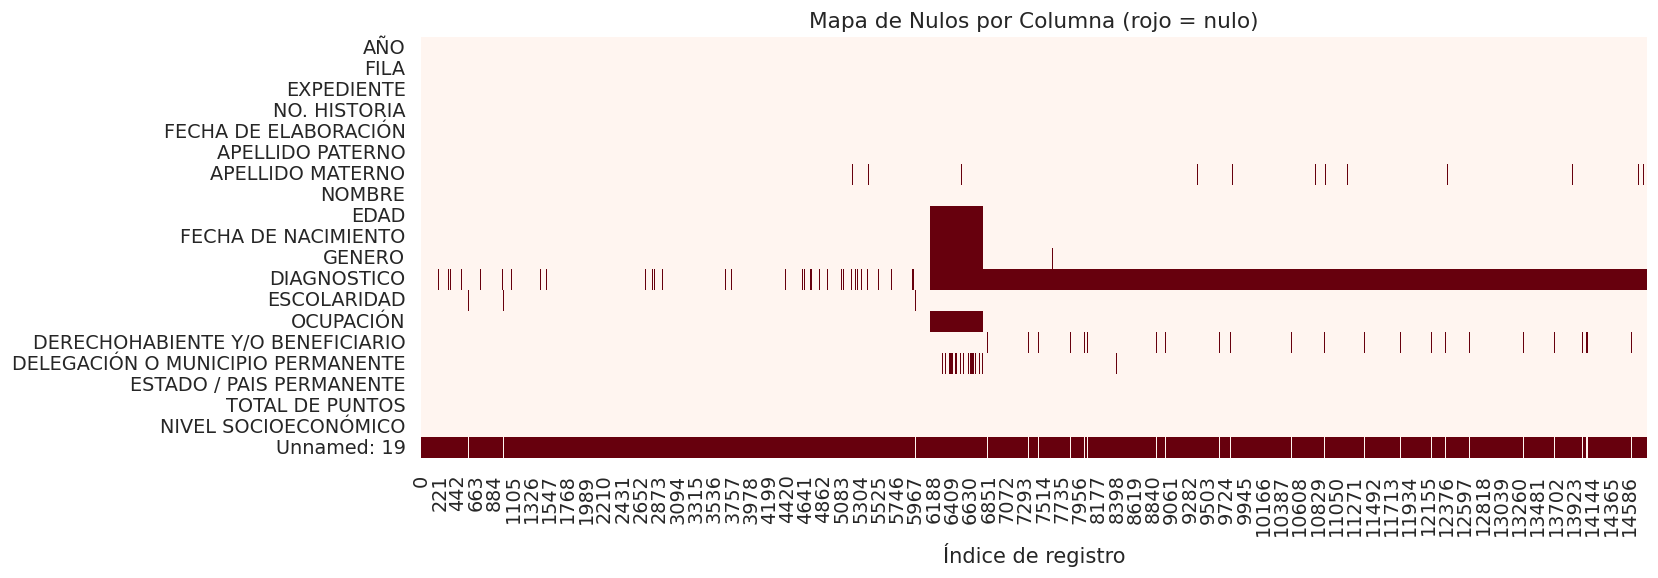

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', yticklabels=True, ax=ax)
ax.set_title('Mapa de Nulos por Columna (rojo = nulo)', fontsize=13)
ax.set_xlabel('Índice de registro')
plt.tight_layout()
plt.savefig(ruta_base / 'Reporte_Consultoría' / 'Figuras' / 'heatmap_nulos_ts.png', dpi=150)
plt.show()

### 1.3 Análisis detallado por tipo de variable

En esta sección, para cada una de las 20 columnas, identificamos su tipo de variable y confirmamos qué información contiene realmente, de acuerdo con las siguientes subsecciones de análisis:

- **1.3.1 Identificadores y Fechas** 
    - `EXPEDIENTE`, `NO. HISTORIA`, `AÑO`, `FILA`, `FECHA DE ELABORACIÓN`, `FECHA DE NACIMIENTO`

- **1.3.2 Variables Categóricas: Demográficas**
    - `APELLIDO PATERNO`, `APELLIDO MATERNO`, `NOMBRE`, `EDAD`, `GENERO`

- **1.3.3 Variables Categóricas: Socioeconómicas**
    - `ESCOLARIDAD`, `OCUPACIÓN`, `DERECHOHABIENTE Y/O BENEFICIARIO`, `TOTAL DE PUNTOS`, `NIVEL SOCIOECONÓMICO`

- **1.3.4 Variables Categóricas: Clínicas y Geográficas**
    - `DIAGNOSTICO`, `DELEGACIÓN O MUNICIPIO PERMANENTE`, `ESTADO / PAIS PERMANENTE`, `Unnamed: 19`

#### 1.3.1 Identificadores y Fechas

In [79]:
cols_id_fecha = ['EXPEDIENTE', 'NO. HISTORIA', 'AÑO', 'FILA']

for col in cols_id_fecha:
    if col not in df.columns:
        continue
    serie = df[col]
    top = serie.value_counts(dropna=False).head(10)
    df_top = top.reset_index()
    df_top.columns = [col, 'Frecuencia']
    display(df_top.style.set_caption(f'Top 10 valores más frecuentes en {col}')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

# --- FECHAS: rango y distribución ---
cols_fecha = ['FECHA DE ELABORACIÓN', 'FECHA DE NACIMIENTO']
rows_fecha = []
for col in cols_fecha:
    serie = df[col].dropna()
    rows_fecha.append({
        'Campo': col, 'Nulos': int(df[col].isna().sum()),
        'Fecha mín': serie.min().strftime('%Y-%m-%d') if len(serie) else '',
        'Fecha máx': serie.max().strftime('%Y-%m-%d') if len(serie) else '',
        'Años cubiertos': sorted(serie.dt.year.unique().tolist()),
    })
display(pd.DataFrame(rows_fecha).style
        .set_caption('Campos de fecha: rango temporal')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Casos donde la fecha de nacimiento es posterior a la de elaboración
anomalos = df[
    (df['FECHA DE NACIMIENTO'].notna()) &
    (df['FECHA DE ELABORACIÓN'].notna()) &
    (df['FECHA DE NACIMIENTO'] > df['FECHA DE ELABORACIÓN'])
]
print(f"Registros con fecha de nacimiento posterior a la de elaboración: {len(anomalos)}")


EXPEDIENTE,Frecuencia
236544,2
236215,1
236216,1
236217,1
236220,1
236221,1
236222,1
236223,1
236224,1
236225,1


NO. HISTORIA,Frecuencia
IAN602397,2
IAN610738,2
IAN600536,1
IAN600533,1
IAN561983,1
IAN486680,1
IAN600607,1
IAN600592,1
IAN600525,1
IAN600609,1


AÑO,Frecuencia
2,6108
0,3035
3,2974
1,2679


FILA,Frecuencia
0,4
1,4
2,4
3,4
4,4
5,4
6,4
7,4
8,4
9,4


Campo,Nulos,Fecha mín,Fecha máx,Años cubiertos
FECHA DE ELABORACIÓN,4120,2019-11-06,2023-05-25,"[2019, 2020, 2021, 2022, 2023]"
FECHA DE NACIMIENTO,651,1916-02-02,2023-02-18,"[1916, 1917, 1919, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]"


Registros con fecha de nacimiento posterior a la de elaboración: 0


#### 1.3.2 Variables Categóricas: Demográficas

In [39]:
# Construir nombre completo concatenado
df['NOMBRE_COMPLETO'] = (
    df['APELLIDO PATERNO'].fillna('') + ' ' +
    df['APELLIDO MATERNO'].fillna('') + ' ' +
    df['NOMBRE'].fillna('')
).str.strip()

cols_cat_demo = ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE', 'NOMBRE_COMPLETO', 'EDAD', 'GENERO']

for col in cols_cat_demo:
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Para campos con muchas categorías, mostrar solo top 10
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                   '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)

    display(df_vc.style
            .format({'%': '{:.1f}%'})
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))


APELLIDO PATERNO,Registros,%
HERNANDEZ,505,3.4%
GARCIA,421,2.8%
MARTINEZ,355,2.4%
GONZALEZ,324,2.2%
SANCHEZ,266,1.8%
LOPEZ,263,1.8%
RODRIGUEZ,231,1.6%
PEREZ,221,1.5%
FLORES,216,1.5%
RAMIREZ,201,1.4%


APELLIDO MATERNO,Registros,%
HERNANDEZ,562,3.8%
GARCIA,447,3.0%
MARTINEZ,429,2.9%
GONZALEZ,338,2.3%
SANCHEZ,336,2.3%
LOPEZ,330,2.2%
RAMIREZ,246,1.7%
PEREZ,242,1.6%
RODRIGUEZ,240,1.6%
FLORES,201,1.4%


NOMBRE,Registros,%
JOSE LUIS,97,0.7%
MIGUEL ANGEL,92,0.6%
ALEJANDRO,89,0.6%
JUAN,84,0.6%
CARLOS,73,0.5%
RICARDO,72,0.5%
FRANCISCO,72,0.5%
JORGE,67,0.5%
ANTONIO,64,0.4%
MARIA GUADALUPE,61,0.4%


NOMBRE_COMPLETO,Registros,%
GONZALEZ GARCIA JOSE LUIS,2,0.0%
PRADO APOLINAR ARMANDO,2,0.0%
GARCIA PEREZ GUADALUPE,2,0.0%
FLORES MENDOZA ROBERTO,2,0.0%
NAVA HERNANDEZ ROBERTO,2,0.0%
MARTINEZ GARCIA GUILLERMINA,2,0.0%
HERNANDEZ HERNANDEZ CAMILA,2,0.0%
GARCIA GONZALEZ CIRILO,2,0.0%
RAMIREZ ANTONIO ANA LILIA,2,0.0%
HERNANDEZ GARCIA ENRIQUE,2,0.0%


EDAD,Registros,%
⟨NaN⟩,651,4.4%
69 Años,155,1.0%
61 Años,154,1.0%
68 Años,147,1.0%
65 Años,145,1.0%
52 Años,143,1.0%
49 Años,141,1.0%
60 Años,140,0.9%
63 Años,139,0.9%
58 Años,136,0.9%


GENERO,Registros,%
Masculino,7918,53.5%
Femenino,6210,42.0%
⟨NaN⟩,668,4.5%


#### 1.3.3 Variables Categóricas: Socioeconómicas

In [7]:
cols_cat_socio = [
    'ESCOLARIDAD', 'OCUPACIÓN', 'DERECHOHABIENTE Y/O BENEFICIARIO',
    'TOTAL DE PUNTOS', 'NIVEL SOCIOECONÓMICO'
]

for col in cols_cat_socio:
    if col not in df.columns:
        continue
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Top 10 + resumen del resto
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                   '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)
    display(df_vc.style
            .format({'%': '{:.1f}%'}) # type: ignore
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

ESCOLARIDAD,Registros,%
Profesional,1305,8.8%
Secundaria Completa,1275,8.6%
Bachillerato o Preparatoria Completa,1176,7.9%
SECUNDARIA COMPLETA,1134,7.7%
SUPERIOR COMPLETO,974,6.6%
Primaria Completa,951,6.4%
Primaria Incompleta,939,6.3%
PRIMARIA COMPLETA,840,5.7%
NMS COMPLETO,721,4.9%
PRIMARIA INCOMPLETA,595,4.0%


OCUPACIÓN,Registros,%
Sin ocupación,4582,31.0%
Hogar,1209,8.2%
Trabajadores no calificados,1183,8.0%
⟨NaN⟩,655,4.4%
DESEMPLEADO,580,3.9%
Becarios Trabajadores de los Servicios y Vendedores de Comercios y Mercados,533,3.6%
Jubilados y pensionados,519,3.5%
INCAPACITADO,441,3.0%
"Profesionistas, científicos e intelectuales",398,2.7%
COMERCIANTE AMBULANTE,374,2.5%


DERECHOHABIENTE Y/O BENEFICIARIO,Registros,%
Ninguno,5640,38.1%
NINGUNO,3993,27.0%
IMSS,2723,18.4%
ISSSTE,1666,11.3%
⟨NaN⟩,249,1.7%
Ninguno,214,1.4%
SEG.POP.,96,0.6%
IMSS,68,0.5%
ISSSTE,46,0.3%
ISSEMYN,30,0.2%


TOTAL DE PUNTOS,Registros,%
24,682,4.6%
16,623,4.2%
17,610,4.1%
18,596,4.0%
15,593,4.0%
19,518,3.5%
20,509,3.4%
14,494,3.3%
23,490,3.3%
22,472,3.2%


NIVEL SOCIOECONÓMICO,Registros,%
1,4970,33.6%
2,3747,25.3%
3,2343,15.8%
4,894,6.0%
1X,810,5.5%
1E,768,5.2%
2E,463,3.1%
5,183,1.2%
3E,152,1.0%
1XE,123,0.8%


#### 1.3.4 Variables Categóricas: Clínicas y Geográficas

In [43]:
cols_cat_clin_geo = [
    'DIAGNOSTICO', 'DELEGACIÓN O MUNICIPIO PERMANENTE',
    'ESTADO / PAIS PERMANENTE', 'Unnamed: 19'
]

for col in cols_cat_clin_geo:
    if col not in df.columns:
        continue
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Top 10 + resumen del resto
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                   '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)

    display(df_vc.style
            .format({'%': '{:.1f}%'})
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

DIAGNOSTICO,Registros,%
⟨NaN⟩,9070,61.3%
Enfermedad respiratoria aguda con contacto o sospecha de exposición a COVID-19,3495,23.6%
"Enfermedad respiratoria aguda debido a Coronavirus, COVID-19",295,2.0%
"Neumonía, organismo no especificado",142,1.0%
Trastornos del sueño,124,0.8%
Otras enfermedades pulmonares intersticiales,101,0.7%
Derrame pleural no clasificado en otra parte,92,0.6%
"Tuberculosis respiratoria, no confirmada bacteriológica o histológicamente",91,0.6%
Otras enfermedades pulmonares obstructivas crónicas,88,0.6%
Asma,88,0.6%


DELEGACIÓN O MUNICIPIO PERMANENTE,Registros,%
TLALPAN,845,5.7%
IZTAPALAPA,817,5.5%
Iztapalapa,776,5.2%
Tlalpan,747,5.0%
COYOACAN,581,3.9%
Coyoacán,455,3.1%
XOCHIMILCO,399,2.7%
ALVARO OBREGON,349,2.4%
GUSTAVO A MADERO,312,2.1%
Xochimilco,298,2.0%


ESTADO / PAIS PERMANENTE,Registros,%
CIUDAD DE MÉXICO,4893,33.1%
"Ciudad de México,Mexico",3814,25.8%
ESTADO DE MÉXICO,2199,14.9%
"México,Mexico",1678,11.3%
MORELOS,176,1.2%
HIDALGO,173,1.2%
GUERRERO,164,1.1%
PUEBLA,136,0.9%
VERACRUZ,123,0.8%
OAXACA,102,0.7%


Unnamed: 19,Registros,%
⟨NaN⟩,14538,98.3%
3,108,0.7%
1,68,0.5%
2,43,0.3%
4,34,0.2%
1E,2,0.0%
5,2,0.0%
2E,1,0.0%


## 2. Calidad para Serialización — Anomalías, Formatos y Campos Críticos

In [ ]:
hallazgos = []

# EDAD: texto libre — analizar formatos
edad_col = df['EDAD'].dropna().astype(str)
tiene_anios = edad_col.str.contains(r'año', case=False, regex=True)
solo_numero = edad_col.str.match(r'^\d+$')
hallazgos.append(('EDAD: formato texto con "años"', f'{tiene_anios.sum()} registros ({tiene_anios.sum()/len(edad_col)*100:.1f}%)'))
hallazgos.append(('EDAD: solo número', f'{solo_numero.sum()} registros ({solo_numero.sum()/len(edad_col)*100:.1f}%)'))
hallazgos.append(('EDAD: otros formatos', f'{(~tiene_anios & ~solo_numero).sum()} registros'))

# EXPEDIENTE: tipo y composición
exp_str = df['EXPEDIENTE'].astype(str).str.strip()
mask_null_exp = df['EXPEDIENTE'].isna()
mask_num_exp = exp_str.str.match(r'^\d+\.?0?$')
hallazgos.append(('EXPEDIENTE: numéricos', f'{mask_num_exp.sum()} ({mask_num_exp.sum()/len(df)*100:.1f}%)'))
hallazgos.append(('EXPEDIENTE: nulos', f'{mask_null_exp.sum()}'))

# NO. HISTORIA: formato
nh = df['NO. HISTORIA'].dropna().astype(str)
patron_nh = nh.str.match(r'^[A-Z]{3}\d{6}$', case=False)
hallazgos.append(('NO. HISTORIA: formato IAN######', f'{patron_nh.sum()} ({patron_nh.sum()/len(nh)*100:.1f}%)'))
hallazgos.append(('NO. HISTORIA: otros formatos', f'{(~patron_nh).sum()} ({(~patron_nh).sum()/len(nh)*100:.1f}%)'))

# Campos nombre: nulos
for col in ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE']:
    n = df[col].isna().sum()
    hallazgos.append((f'{col}: nulos', f'{n} ({n/len(df)*100:.1f}%)'))

# Trailing spaces en categóricas
for col in ['ESCOLARIDAD', 'OCUPACIÓN', 'DERECHOHABIENTE Y/O BENEFICIARIO', 'GENERO']:
    if col in df.columns:
        vals = df[col].dropna()
        orig = vals.nunique()
        norm = vals.astype(str).str.strip().str.upper().nunique()
        if orig != norm:
            hallazgos.append((f'{col}: trailing spaces', f'{orig} → {norm} categorías al normalizar'))

df_hallazgos = pd.DataFrame(hallazgos, columns=['Anomalía', 'Detalle'])
df_hallazgos.index = range(1, len(df_hallazgos) + 1)
df_hallazgos.index.name = '#'
display(df_hallazgos.style.set_caption('2.1 — Hallazgos de calidad')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}]))

,Anomalía,Detalle
#,,
1,"EDAD: formato texto con ""años""",14145 registros (100.0%)
2,EDAD: solo número,0 registros (0.0%)
3,EDAD: otros formatos,0 registros
4,EXPEDIENTE: numéricos,14796 (100.0%)
5,EXPEDIENTE: nulos,0
6,NO. HISTORIA: formato IAN######,14794 (100.0%)
7,NO. HISTORIA: otros formatos,2 (0.0%)
8,APELLIDO PATERNO: nulos,1 (0.0%)
9,APELLIDO MATERNO: nulos,99 (0.7%)


### 2.1 Análisis de los campos separados relacionados con el nombre del paciente

A diferencia de los otros CSV, aquí el nombre está separado en tres campos:
- `APELLIDO PATERNO`
- `APELLIDO MATERNO`
- `NOMBRE`

Para la serialización, se pueden concatenar en un formato unificado.

#### 2.1.1 Estructura de las columnas `APELLIDO PATERNO`, `APELLIDO MATERNO`, `NOMBRE`

In [37]:
name_cols = ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE']

for col in name_cols:
    valor = df[col].dropna()
    n_tokens = valor.str.split().apply(len)
    # Detectar valor con múltiples espacios
    nombres_multi_espacio = int(valor.str.contains(r'  +', regex=True).sum())

    # Agregar a la tabla de métricas
    df_nombre = pd.DataFrame([
        {'Métrica': f'Tokens por {col}', 'Valor': f"{int(n_tokens.min())} (mínimo), {int(n_tokens.max())} (máximo)"},
        {'Métrica': f'{col} con espacios múltiples', 'Valor': nombres_multi_espacio},
        {'Métrica': f'{col} con 2 tokens', 'Valor': int((n_tokens == 2).sum())},
        {'Métrica': f'{col} con 5 tokens o más', 'Valor': int((n_tokens >= 5).sum())},
    ])
    display(df_nombre.style
            .set_caption(f'Columna {col}: estructura del texto libre')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))
    # Nombres con espacios múltiples. Reemplazamos por "--" para visualizar
    mask_espacios = df[col].str.contains(r'\s{2,}')
    df_espacios = df.loc[valor[mask_espacios].index, [col, 'EXPEDIENTE']].copy()
    df_espacios[col] = df_espacios[col].str.replace(r'\s{2,}', '--', regex=True)
    display(
        df_espacios.head(5)
        .style
        .set_caption(f"{col} con espacios múltiples: {mask_espacios.sum()} registros afectados")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
        .hide(axis='index')
    )

    # --- Nombres con 2 tokens (posible truncamiento) ---
    mask_2t = n_tokens == 2
    if mask_2t.sum() > 0:
        display(df.loc[valor[mask_2t].index, [col, 'EXPEDIENTE']].head(5)
            .style
            .set_caption(f"{col} con 2 tokens: {mask_2t.sum()} registros afectados")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
            .hide(axis='index'))

    # Nombres con 5 o más tokens
    mask_5t = n_tokens >= 5
    display(
        df.loc[valor[mask_5t].index, [col, 'EXPEDIENTE']].head(5)
        .style
        .set_caption(f"{col} con 5 o más tokens: {mask_5t.sum()} registros afectados")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
        .hide(axis='index')
)


Métrica,Valor
Tokens por APELLIDO PATERNO,"1 (mínimo), 5 (máximo)"
APELLIDO PATERNO con espacios múltiples,4
APELLIDO PATERNO con 2 tokens,638
APELLIDO PATERNO con 5 tokens o más,3


APELLIDO PATERNO,EXPEDIENTE
SANTA--CRUZ,239984
NAVA--,240322
DE LOS--SANTOS,241289
IRAIS--ABIGAIL,244172


APELLIDO PATERNO,EXPEDIENTE
SANTO TOMAS,236223
DEL VALLE,236261
RIVA PALACIO,236269
DE LUCIO,236397
RINCON GALLARDO,236405


APELLIDO PATERNO,EXPEDIENTE
MARIA DE LA LUZ ISIDRA,243315
PATRICIA MARIA DE LOS ANGELES,243584
MARIA DE LOS ANGELES GUADALUPE,243672


Métrica,Valor
Tokens por APELLIDO MATERNO,"1 (mínimo), 4 (máximo)"
APELLIDO MATERNO con espacios múltiples,2
APELLIDO MATERNO con 2 tokens,141
APELLIDO MATERNO con 5 tokens o más,0


...

APELLIDO MATERNO,EXPEDIENTE


Métrica,Valor
Tokens por NOMBRE,"1 (mínimo), 8 (máximo)"
NOMBRE con espacios múltiples,39
NOMBRE con 2 tokens,5715
NOMBRE con 5 tokens o más,16


NOMBRE,EXPEDIENTE
CATALINA--ALEJANDRA,236287
BERTYOMAR--JOSE DEL VALLE,236493
SOPHIA--GUADALUPE,236510
MA--DEL REFUGIO,236572
DULCE--KAROLINA,236761


NOMBRE,EXPEDIENTE
SHEILA YADIRA,236215
JOSE LUIS,236216
ANNIE SOFIA,236217
BRAYAN ANAEL,236224
VICTOR HUGO,236228


NOMBRE,EXPEDIENTE
MARIA DE LA LUZ IGNACIA,236542
MARIA GUADALUPE DE LA LUZ,238502
MARIA GUADALUPE DEL PERPETUO S,238630
MARIA DE LOS ANGELES LAMBERTA,239176
MARIA ESTHER DEL SAGRADO CORAZ,241433


#### 2.1.2 Caracteres problemáticos

In [38]:
patron_problematico = re.compile(r'[^A-ZÁÉÍÓÚÜÑ \-]', re.IGNORECASE)

for col in name_cols:
    vals = df[col].dropna()
    problemas = vals.apply(lambda x: set(patron_problematico.findall(str(x))))
    con_problemas = problemas[problemas.apply(len) > 0]
    if len(con_problemas) > 0:
        conteo = Counter()
        for chars in con_problemas:
            conteo.update(chars)
        rows_ch = []
        for char, n in conteo.most_common(5):
            ej = vals[vals.str.contains(re.escape(char), na=False)].head(2).tolist()
            rows_ch.append({'Carácter': repr(char), 'Registros': n,
                            'Ejemplo': ej[0] if ej else ''})
        display(pd.DataFrame(rows_ch).style.set_caption(f'Caracteres problemáticos en {col}: {len(con_problemas)} registros afectados ({len(con_problemas)/len(vals)*100:.1f}%)')
                .bar(subset=['Registros'], color='#1428a7')
                .set_table_styles([{'selector': 'caption', 'props': 'font-size:1em; font-weight:bold'}]))
    else:
        print(f"{col}: Sin caracteres problemáticos")

for col in name_cols:
    serie = df[col].dropna()
    mask_nbsp = serie.str.contains('\xa0', regex=False)
    ejemplos = serie[mask_nbsp].head(5).apply(lambda x: x.replace('\xa0', '[NBSP]'))
    print(f"\n{col} — Ejemplos con non-breaking space (\\xa0):")
    for ej in ejemplos:
        print(ej)

,Carácter,Registros,Ejemplo
0,'.',67,.
1,'\xa0',27,RAMIREZ
2,'/',2,S/R
3,'|',2,|SALES
4,'Ì',1,RODRÌGUEZ


,Carácter,Registros,Ejemplo
0,'.',36,.
1,'\xa0',2,HERRERA
2,"','",1,","


,Carácter,Registros,Ejemplo
0,'.',122,MA. CARMEN
1,'/',30,R/N
2,'\xa0',29,ENRIQUETA NOETZEL
3,'|',1,GUILLEN|
4,'0',1,ANT0NIO



APELLIDO PATERNO — Ejemplos con non-breaking space (\xa0):
RAMIREZ[NBSP]
PEREZ[NBSP]
GARCIA[NBSP]
RAMOS[NBSP]
HERNANDEZ[NBSP]

APELLIDO MATERNO — Ejemplos con non-breaking space (\xa0):
[NBSP]HERRERA
RAMOS[NBSP]

NOMBRE — Ejemplos con non-breaking space (\xa0):
ENRIQUETA NOETZEL[NBSP]
[NBSP]CELIA[NBSP]
JOSE CARLOS[NBSP]
JUAN[NBSP]
KARLA[NBSP]


#### 2.1.3 Nombres duplicados + conflictos expediente - nombre Original vs Normalizado

In [52]:
# --- Nombres duplicados y cuasi-duplicados ---
def normalizar_nombre(texto):
    if pd.isna(texto):
        return ''
    s = str(texto).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^A-Z ]', '', s)
    s = ' '.join(s.split())
    return s

# Construir nombre completo concatenado para análisis
df['nombre_completo'] = (df['APELLIDO PATERNO'].fillna('') + ' ' +
                           df['APELLIDO MATERNO'].fillna('') + ' ' +
                           df['NOMBRE'].fillna('')).str.strip()

# Duplicados antes de normalizar
nombre_counts_raw = df['nombre_completo'].value_counts()
num_nombres_duplicados_raw = (nombre_counts_raw > 1).sum()
num_registros_duplicados_raw = df['nombre_completo'].isin(nombre_counts_raw[nombre_counts_raw > 1].index).sum()

# Duplicados después de normalizar
df['nombre_norm'] = df['nombre_completo'].apply(normalizar_nombre)
nombre_counts_norm = df['nombre_norm'].value_counts()
num_nombres_duplicados_norm = (nombre_counts_norm > 1).sum()
num_registros_duplicados_norm = df['nombre_norm'].isin(nombre_counts_norm[nombre_counts_norm > 1].index).sum()

# Tabla comparativa
df_comparativa = pd.DataFrame([
    {'Estado': 'Sin normalizar', 'Nombres duplicados': num_nombres_duplicados_raw, 'Registros afectados': num_registros_duplicados_raw},
    {'Estado': 'Normalizado', 'Nombres duplicados': num_nombres_duplicados_norm, 'Registros afectados': num_registros_duplicados_norm}
])
display(
    df_comparativa.style
    .set_caption("Nombres repetidos antes y después de normalizar")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)


# Top duplicados normalizados
dup_nombres = df['nombre_norm'].value_counts()
dup_nombres = dup_nombres[dup_nombres > 1]

rows_dup = []
for nombre, count in dup_nombres.head(10).items():
    registros = df[df['nombre_norm'] == nombre]
    expedientes = registros['EXPEDIENTE'].dropna().unique()
    rows_dup.append({
        'Nombre normalizado': nombre,
        'Repeticiones': count,
        'Expedientes únicos': len(expedientes),
        'Expediente': ', '.join(str(e) for e in expedientes[:5]) + ('...' if len(expedientes) > 5 else '')
    })

df_dup = pd.DataFrame(rows_dup)
display(
    df_dup.style
    .set_caption('TOP 10 nombres más repetidos')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Expedientes con múltiples nombres distintos
dup_exp = df[df['EXPEDIENTE'].notna()].groupby('EXPEDIENTE')['nombre_norm'].nunique()
exp_multi_nombre = dup_exp[dup_exp > 1]

if len(exp_multi_nombre) > 0:
    rows_conflicto = []
    for exp in exp_multi_nombre.index[:10]:  # top 10
        registros = df[df['EXPEDIENTE'] == exp]
        for _, r in registros.head(5).iterrows():
            rows_conflicto.append({
                'EXPEDIENTE': exp,
                'NOMBRE COMPLETO': r['nombre_completo'],
                'FECHA': r.get('FECHA DE ELABORACIÓN', ''),
            })
    df_conflicto = pd.DataFrame(rows_conflicto)
    print(f"\nExpedientes con >1 nombre distinto: {len(exp_multi_nombre)}")
    display(df_conflicto.style.set_caption('EXPEDIENTE con múltiples nombres (conflictos)')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold; color: #c0392b'}]))
else:
    print('\n✓ No se encontraron expedientes con múltiples nombres distintos.')

Estado,Nombres duplicados,Registros afectados
Sin normalizar,12,24
Normalizado,13,26


Nombre normalizado,Repeticiones,Expedientes únicos,Expediente
GONZALEZ GARCIA JOSE LUIS,2,1,236544
PRADO APOLINAR ARMANDO,2,2,"237574, 237771"
GARCIA PEREZ GUADALUPE,2,2,"237588, 242094"
FLORES MENDOZA ROBERTO,2,2,"238015, 246529"
NAVA HERNANDEZ ROBERTO,2,2,"238708, 246142"
MARTINEZ GARCIA GUILLERMINA,2,2,"239322, 248007"
HERNANDEZ HERNANDEZ CAMILA,2,2,"240431, 241926"
GARCIA GONZALEZ CIRILO,2,2,"241296, 246880"
RAMIREZ ANTONIO ANA LILIA,2,2,"242423, 242847"
HERNANDEZ GARCIA ENRIQUE,2,2,"242435, 242996"



✓ No se encontraron expedientes con múltiples nombres distintos.


### 2.2 Análisis de `EXPEDIENTE` y `NO. HISTORIA`: Identificadores primarios con formato mixto

In [68]:
exp_col = df['EXPEDIENTE'].astype(str).str.strip()
mask_null_exp = df['EXPEDIENTE'].isna()
mask_num_exp = exp_col.str.match(r'^\d+\.?0?$')
mask_num_int = exp_col.str.match(r'^\d+$')
mask_se = exp_col.str.upper() == 'S/E'

df_exp = pd.DataFrame([
    {'Tipo de Valor': 'Numéricos puros', 'Cantidad': int(mask_num_exp.sum()), '%': round(mask_num_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'NaN / vacíos', 'Cantidad': int(mask_null_exp.sum()), '%': round(mask_null_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'S/E', 'Cantidad': int(mask_se.sum()), '%': round(mask_se.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Otros formatos', 'Cantidad': int((~mask_null_exp & ~mask_num_exp & ~mask_se).sum()), '%': round((~mask_null_exp & ~mask_num_exp & ~mask_se).sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Únicos (numéricos)', 'Cantidad': int(df.loc[mask_num_exp, 'EXPEDIENTE'].nunique()), '%': round(df.loc[mask_num_exp, 'EXPEDIENTE'].nunique() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Únicos (enteros)', 'Cantidad': int(df.loc[mask_num_int, 'EXPEDIENTE'].nunique()), '%': round(df.loc[mask_num_int, 'EXPEDIENTE'].nunique() / len(df) * 100, 1)},
])
display(df_exp.style
        .format({'%': '{:.1f}%'}, na_rep='—')
        .bar(subset=['Cantidad'], color='#1428a7')
        .set_caption('Columna `EXPEDIENTE`: composición del identificador')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


# NO. HISTORIA
nh = df['NO. HISTORIA'].dropna().astype(str)
patron_nh = nh.str.match(r'^[A-Z]{3}\d{6}$', case=False)

df_nh_tipos = pd.DataFrame([
    {'Categoría': 'Formato IAN######', 'Registros': int(patron_nh.sum()),
     '%': round(patron_nh.sum()/len(nh)*100, 1)},
    {'Categoría': 'Otros formatos', 'Registros': int((~patron_nh).sum()),
     '%': round((~patron_nh).sum()/len(nh)*100, 1)},
])
display(df_nh_tipos.style
        .format({'%': '{:.1f}%'})
        .set_caption('NO. HISTORIA: Composición de valores')
        .bar(subset=['Registros'], color='#1428a7')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


# Duplicados en EXP
exp_counts = df['EXPEDIENTE'].value_counts()
exp_duplicados = exp_counts[exp_counts > 1]

# Tabla comparativa
df_exp_comparativa = pd.DataFrame([
    {'Estado': 'EXP', 'Expedientes duplicados': len(exp_duplicados), 'Registros afectados':df['EXPEDIENTE'].isin(exp_duplicados.index).sum() }
])

display(df_exp_comparativa.style
    .set_caption("Duplicados en EXP")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index'))

# Rango y saltos grandes en EXP numéricos enteros
exp_num = df.loc[mask_num_int, 'EXPEDIENTE'].astype(int)
exp_sorted = exp_num.sort_values().unique()
exp_diff = pd.Series(exp_sorted[1:] - exp_sorted[:-1])

df_exp_rango = pd.DataFrame([{
    'Valor mínimo': exp_num.min(),
    'Valor máximo': exp_num.max(),
    'Saltos grandes (>1)': (exp_diff > 1).sum()
}])

display(
    df_exp_rango.style
    .set_caption("Secuencia y rango de valores numéricos en EXP")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

Tipo de Valor,Cantidad,%
Numéricos puros,14796,100.0%
NaN / vacíos,0,0.0%
S/E,0,0.0%
Otros formatos,0,0.0%
Únicos (numéricos),14795,100.0%
Únicos (enteros),14795,100.0%


Categoría,Registros,%
Formato IAN######,14794,100.0%
Otros formatos,2,0.0%


Estado,Expedientes duplicados,Registros afectados
EXP,1,2


Valor mínimo,Valor máximo,Saltos grandes (>1)
236215,251119,64


### 2.3 Análisis del campo `EDAD` — Texto libre con formato inconsistente

In [69]:
edad_col = df['EDAD'].dropna().astype(str)

# Extraer años numéricos del texto
def extraer_anios(texto):
    m = re.match(r'(\d+)\s*año', str(texto), re.IGNORECASE)
    if m:
        return int(m.group(1))
    m2 = re.match(r'^(\d+)$', str(texto).strip())
    if m2:
        return int(m2.group(1))
    return None

df['edad_num'] = df['EDAD'].apply(extraer_anios)

# Formatos encontrados
formatos = []
patron_completo = edad_col.str.match(r'^\d+ años? \d+ meses? \d+ días?', case=False)
patron_parcial = edad_col.str.match(r'^\d+ años?', case=False) & ~patron_completo
patron_numerico = edad_col.str.match(r'^\d+$')
patron_meses = edad_col.str.match(r'^\d+ meses?', case=False)
patron_dias = edad_col.str.match(r'^\d+ días?', case=False)

formatos = [
    {'Formato': '"X años Y meses Z días"', 'Registros': int(patron_completo.sum()), '%': round(patron_completo.sum()/len(edad_col)*100, 1)},
    {'Formato': '"X años ..." (parcial)', 'Registros': int(patron_parcial.sum()), '%': round(patron_parcial.sum()/len(edad_col)*100, 1)},
    {'Formato': 'Solo número', 'Registros': int(patron_numerico.sum()), '%': round(patron_numerico.sum()/len(edad_col)*100, 1)},
    {'Formato': '"X meses..." (bebés)', 'Registros': int(patron_meses.sum()), '%': round(patron_meses.sum()/len(edad_col)*100, 1)},
    {'Formato': '"X días..."', 'Registros': int(patron_dias.sum()), '%': round(patron_dias.sum()/len(edad_col)*100, 1)},
]
resto = len(edad_col) - sum(f['Registros'] for f in formatos)
if resto > 0:
    formatos.append({'Formato': 'Otros', 'Registros': resto, '%': round(resto/len(edad_col)*100, 1)})

df_formatos = pd.DataFrame(formatos)
display(df_formatos.style
        .format({'%': '{:.1f}%'})
        .set_caption('Formatos detectados en EDAD')
        .bar(subset=['Registros'], color="#1428a7")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Detectar registros con edad extrema (<1 o >100)
edad_extremos = df[(df['edad_num'] < 1) | (df['edad_num'] > 100)]

display(
    edad_extremos[['EXPEDIENTE', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE', 'EDAD', 'edad_num']].head(10)
    .style
    .format({'edad_num': '{:.1f}'})
    .set_caption(f"Registros con EDAD extrema (<1 o >100): {len(edad_extremos)} casos")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

Formato,Registros,%
"""X años Y meses Z días""",6133,43.4%
"""X años ..."" (parcial)",8012,56.6%
Solo número,0,0.0%
"""X meses..."" (bebés)",0,0.0%
"""X días...""",0,0.0%


EXPEDIENTE,APELLIDO PATERNO,APELLIDO MATERNO,NOMBRE,EDAD,edad_num
236242,ZARATE,SANDOVAL,ITZAE,0 años 7 meses 18 días,0.0
236301,GONZALEZ,GARCIA,DANIEL EMILIANO,0 años 9 meses 11 días,0.0
236424,VILLAGOMEZ,BRAVO,ELOISA,102 años 9 meses 9 días,102.0
236446,GONZALEZ,GARCIA,SIN REGISTRO,0 años 1 meses 23 días,0.0
236470,MALDONADO,GARCIA,SIN REGISTRO,0 años 5 meses 7 días,0.0
236540,RIOS,GUERRERO,MIA AITANA,0 años 10 meses 7 días,0.0
236696,RABAGO,PEREZ,ALINA YAELI,0 años 10 meses 20 días,0.0
236714,MARTINEZ,BLANCO,JUAN ALEXIS,0 años 6 meses 20 días,0.0
236715,TIBURCIO,GONZALEZ,CRISTOPHER,0 años 8 meses 15 días,0.0
236988,VENTURA,ESCOBEDO,SARA LIZETH,0 años 4 meses 18 días,0.0


### 2.4 Fechas 

In [ ]:
# ── 2.6  FECHAS — Candidatos a Span Typing <DATE> ──────────────────────────
cols_fecha = ['FECHA DE ELABORACIÓN', 'FECHA DE NACIMIENTO']

rows_fecha = []
for col in cols_fecha:
    if col not in df.columns:
        continue
    serie = df[col]
    n_null = int(serie.isna().sum())
    n_ok = int(serie.notna().sum())
    fechas = serie.dropna()
    rows_fecha.append({
        'Campo': col, 'No nulos': n_ok, 'Nulos': n_null,
        'Fecha mín': fechas.min().strftime('%Y-%m-%d') if n_ok else '',
        'Fecha máx': fechas.max().strftime('%Y-%m-%d') if n_ok else '',
    })
display(pd.DataFrame(rows_fecha).style.set_caption('Resumen de campos de fecha')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


anios = df['FECHA DE ELABORACIÓN'].dropna().dt.year.value_counts().sort_index()
df_anios = anios.reset_index()
df_anios.columns = ['AÑO', 'Registros']
display(df_anios.style.set_caption(f'Distribución por año (FECHA DE ELABORACIÓN)')
        .bar(subset=['Registros'], color="#1428a7")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

Campo,No nulos,Nulos,Fecha mín,Fecha máx
FECHA DE ELABORACIÓN,10676,4120,2019-11-06,2023-05-25
FECHA DE NACIMIENTO,14145,651,1916-02-02,2023-02-18


AÑO,Registros
2019,2
2020,1208
2021,1083
2022,5496
2023,2887


### 2.5 AÑO: análisis de consistencia con FECHA DE ELABORACIÓN

In [7]:
# Con todos los registros
tabla_completa = (
    df.groupby('AÑO')['FECHA DE ELABORACIÓN']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'Fecha mín', 'max': 'Fecha máx', 'count': 'Registros'})
    .reset_index()
)

# Sin los 2 registros de 2019
df_sin2019 = df[~(df['FECHA DE ELABORACIÓN'].dt.year == 2019)]
tabla_sin2019 = (
    df_sin2019.groupby('AÑO')['FECHA DE ELABORACIÓN']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'Fecha mín', 'max': 'Fecha máx', 'count': 'Registros'})
    .reset_index()
)
display(
    tabla_completa.style
    .bar(subset=['Registros'], color='#1428a7')
    .set_caption('AÑO vs FECHA DE ELABORACIÓN — todos los registros')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

display(
    tabla_sin2019.style
    .bar(subset=['Registros'], color='#1428a7')
    .set_caption('AÑO vs FECHA DE ELABORACIÓN — sin registros de 2019 (2 excluidos)')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)


AÑO,Fecha mín,Fecha máx,Registros
0,2019-11-06 00:00:00,2020-12-12 23:10:00,1208
1,2020-12-09 14:46:00,2021-12-12 19:34:00,1084
2,2021-12-30 00:00:00,2022-12-25 00:00:00,5410
3,2022-12-01 00:00:00,2023-05-25 00:00:00,2974


AÑO,Fecha mín,Fecha máx,Registros
0,2020-01-01 00:20:00,2020-12-12 23:10:00,1206
1,2020-12-09 14:46:00,2021-12-12 19:34:00,1084
2,2021-12-30 00:00:00,2022-12-25 00:00:00,5410
3,2022-12-01 00:00:00,2023-05-25 00:00:00,2974


### 2.6 FILA: análisis para detectar qué informacion contiene realmente

In [91]:
fila_unique = df['FILA'].nunique()
fila_total = len(df)
fila_min, fila_max = df['FILA'].min(), df['FILA'].max()
faltantes = set(range(int(fila_min), int(fila_max)+1)) - set(df['FILA'].astype(int))
df_fila_resumen = pd.DataFrame([{
    'Valores únicos': fila_unique,
    'Registros totales': fila_total,
    'Valor mínimo': fila_min,
    'Valor máximo': fila_max,
    'Faltantes en secuencia': len(faltantes)
}])
display(df_fila_resumen.style.set_caption('Resumen de FILA').hide(axis='index'))

# Frecuencias de FILA
fila_freq = df['FILA'].value_counts().value_counts().sort_index()
df_fila_freq = fila_freq.rename_axis('Repeticiones por FILA').reset_index(name='Cantidad de FILA')
display(df_fila_freq.style.set_caption('Frecuencia de repetición por FILA').hide(axis='index'))

# Coincidencia con índice
fila_index_match = (df['FILA'].reset_index(drop=True) == df.index).sum()
print(f"FILA coincide con el índice en {fila_index_match} registros de {fila_total}")

# Ejemplos de FILA más frecuentes
for fila_val in df['FILA'].value_counts().index[:3]:
    ejemplos = df[df['FILA'] == fila_val][['FILA', 'EXPEDIENTE', 'NO. HISTORIA', 'FECHA DE ELABORACIÓN']].head()
    display(ejemplos.style.set_caption(f'Ejemplos para FILA={fila_val}').hide(axis='index'))

Valores únicos,Registros totales,Valor mínimo,Valor máximo,Faltantes en secuencia
6108,14796,0,6107,0


Repeticiones por FILA,Cantidad de FILA
1,3073
2,61
3,295
4,2679


FILA coincide con el índice en 3035 registros de 14796


FILA,EXPEDIENTE,NO. HISTORIA,FECHA DE ELABORACIÓN
0,236215,IAN600536,2020-01-01 10:51:00
0,239293,IAN626352,2021-01-01 08:11:00
0,242015,IAN676793,NaT
0,248145,IAN716363,2022-12-26 00:00:00


FILA,EXPEDIENTE,NO. HISTORIA,FECHA DE ELABORACIÓN
1,236216,IAN600533,2020-01-01 07:05:00
1,239297,IAN626350,2021-01-01 02:00:00
1,242016,IAN676797,NaT
1,248146,IAN711760,2022-12-26 00:00:00


FILA,EXPEDIENTE,NO. HISTORIA,FECHA DE ELABORACIÓN
2,236217,IAN561983,2020-01-01 11:50:00
2,239298,IAN626354,2021-01-01 14:52:00
2,242017,IAN676798,NaT
2,248147,IAN254563,2022-12-25 00:00:00


### 2.6 Inconsistencias en las variables categóricas

In [ ]:
cols_cat = ['ESCOLARIDAD', 'OCUPACIÓN', 'DERECHOHABIENTE Y/O BENEFICIARIO', 'GENERO', 'NIVEL SOCIOECONÓMICO', 'DIAGNOSTICO','DELEGACIÓN O MUNICIPIO PERMANENTE', 'ESTADO / PAIS PERMANENTE']

rows_resumen = []
for col in cols_cat:
    if col not in df.columns:
        continue
    vals = df[col].dropna()
    unicos = vals.unique()
    norm = vals.astype(str).str.strip().str.upper()
    unicos_norm = norm.unique()
    vc = vals.value_counts()
    singletons = int((vc == 1).sum())
    rows_resumen.append({
        'Campo': col,
        'Categorías': len(unicos),
        'Cat. normalizadas': len(unicos_norm),
        'Nulos': int(df[col].isna().sum()),
        '% Nulos': round(df[col].isna().sum() / len(df) * 100, 1),
        'Singletons': singletons,
        'Normalización': 'Sí reduce' if len(unicos_norm) < len(unicos) else 'No reduce',
    })

df_cat_resumen = pd.DataFrame(rows_resumen)
display(df_cat_resumen.style
        .format({'% Nulos': '{:.1f}%'})
        .set_caption('Campos categóricos tras normalización')
        .background_gradient(subset=['% Nulos'], cmap='OrRd')
        .background_gradient(subset=['Singletons'], cmap='YlOrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

Campo,Categorías,Cat. normalizadas,Nulos,% Nulos,Singletons,Normalización
ESCOLARIDAD,49,25,19,0.100000,3,Sí reduce
OCUPACIÓN,265,265,655,4.400000,61,No reduce
DERECHOHABIENTE Y/O BENEFICIARIO,29,23,249,1.700000,12,Sí reduce
GENERO,2,2,668,4.500000,0,No reduce
NIVEL SOCIOECONÓMICO,60,60,5,0.000000,11,No reduce
DIAGNOSTICO,165,165,9070,61.300000,61,No reduce
DELEGACIÓN O MUNICIPIO PERMANENTE,1073,759,251,1.700000,514,Sí reduce
ESTADO / PAIS PERMANENTE,143,137,7,0.000000,48,Sí reduce


## 3. Bloques Semánticos y Presupuesto de Tokens

Mapeamos cada columna a los bloques semánticos. Este CSV aporta los únicos datos **geográficos** y **socioeconómicos** para el cruce, además de un formato de nombre separado que es valioso para la normalización cross-database.

In [3]:
# ── 3.1  Mapeo de columnas a bloques semánticos ──────────────────────────────

# Mapeo basado en 04_Diccionario_Datos_Objetivo.csv
# Campos de "Otros / Revisar" asignados manualmente:
#   AÑO, FILA → metadatos administrativos
#   FECHA DE ELABORACIÓN → BLK_ADMIN
#   OCUPACIÓN → BLK_SOCIO
#   DERECHOHABIENTE Y/O BENEFICIARIO → BLK_SOCIO
#   TOTAL DE PUNTOS → BLK_SOCIO
bloques = {
    '[BLK_ID]':   ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE',
                    'EDAD', 'FECHA DE NACIMIENTO', 'GENERO'],
    '[BLK_CLIN]': ['DIAGNOSTICO'],
    '[BLK_GEO]':  ['DELEGACIÓN O MUNICIPIO PERMANENTE', 'ESTADO / PAIS PERMANENTE'],
    '[BLK_SOCIO]': ['ESCOLARIDAD', 'OCUPACIÓN',
                     'DERECHOHABIENTE Y/O BENEFICIARIO',
                     'TOTAL DE PUNTOS', 'NIVEL SOCIOECONÓMICO'],
    '[BLK_ADMIN]': ['EXPEDIENTE', 'NO. HISTORIA', 'FECHA DE ELABORACIÓN',
                     'AÑO', 'FILA'],
}

# Tabla resumen de completitud por bloque
rows_blk = []
for blk_name, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    sub = df[cols_exist]
    n_all_ok = int(sub.notna().all(axis=1).sum())
    n_all_null = int(sub.isna().all(axis=1).sum())
    n_parcial = len(df) - n_all_null - n_all_ok
    nulos_cols = {c: int(df[c].isna().sum()) for c in cols_exist if df[c].isna().sum() > 0}
    rows_blk.append({
        'Bloque': blk_name,
        'Columnas': len(cols_exist),
        '% Completo': round(n_all_ok / len(df) * 100, 1),
        '% Parcial': round(n_parcial / len(df) * 100, 1),
        '% Vacío': round(n_all_null / len(df) * 100, 1),
        'Campos con nulos': ', '.join(f'{c} ({v})' for c, v in nulos_cols.items()) if nulos_cols else '—',
    })

df_bloques = pd.DataFrame(rows_blk)
display(df_bloques.style.set_caption('Completitud por bloque semántico')
        .background_gradient(subset=['% Completo'], cmap='Greens')
        .background_gradient(subset=['% Vacío'], cmap='Reds')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

# Tabla detallada
rows_detalle = []
for blk_name, cols in bloques.items():
    for c in cols:
        existe = c in df.columns
        nulos = int(df[c].isna().sum()) if existe else '—'
        rows_detalle.append({
            'Bloque': blk_name,
            'Columna': c,
            'Existe': '✓' if existe else '✗',
            'Nulos': nulos,
            '% Nulos': round(nulos / len(df) * 100, 1) if isinstance(nulos, int) else '—',
        })

df_detalle_blk = pd.DataFrame(rows_detalle)
display(df_detalle_blk.style.set_caption('Detalle de columnas por bloque')
        .background_gradient(subset=['% Nulos'], cmap='OrRd', vmin=0, vmax=70)
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

Bloque,Columnas,% Completo,% Parcial,% Vacío,Campos con nulos
[BLK_ID],6,94.700000,5.300000,0.000000,"APELLIDO PATERNO (1), APELLIDO MATERNO (99), NOMBRE (19), EDAD (651), FECHA DE NACIMIENTO (651), GENERO (668)"
[BLK_CLIN],1,38.700000,0.000000,61.300000,DIAGNOSTICO (9070)
[BLK_GEO],2,98.300000,1.600000,0.000000,"DELEGACIÓN O MUNICIPIO PERMANENTE (251), ESTADO / PAIS PERMANENTE (7)"
[BLK_SOCIO],5,93.800000,6.100000,0.000000,"ESCOLARIDAD (19), OCUPACIÓN (655), DERECHOHABIENTE Y/O BENEFICIARIO (249), TOTAL DE PUNTOS (5), NIVEL SOCIOECONÓMICO (5)"
[BLK_ADMIN],5,100.000000,0.000000,0.000000,—


Bloque,Columna,Existe,Nulos,% Nulos
[BLK_ID],APELLIDO PATERNO,✓,1,0.000000
[BLK_ID],APELLIDO MATERNO,✓,99,0.700000
[BLK_ID],NOMBRE,✓,19,0.100000
[BLK_ID],EDAD,✓,651,4.400000
[BLK_ID],FECHA DE NACIMIENTO,✓,651,4.400000
[BLK_ID],GENERO,✓,668,4.500000
[BLK_CLIN],DIAGNOSTICO,✓,9070,61.300000
[BLK_GEO],DELEGACIÓN O MUNICIPIO PERMANENTE,✓,251,1.700000
[BLK_GEO],ESTADO / PAIS PERMANENTE,✓,7,0.000000
[BLK_SOCIO],ESCOLARIDAD,✓,19,0.100000


Métrica,Tokens
Mínimo,77
Mediana,109
Media,112.700000
P90,124
P95,125
P99,128
Máximo,134
Exceden 128,83 (0.6%)
Exceden 256,0 (0.0%)


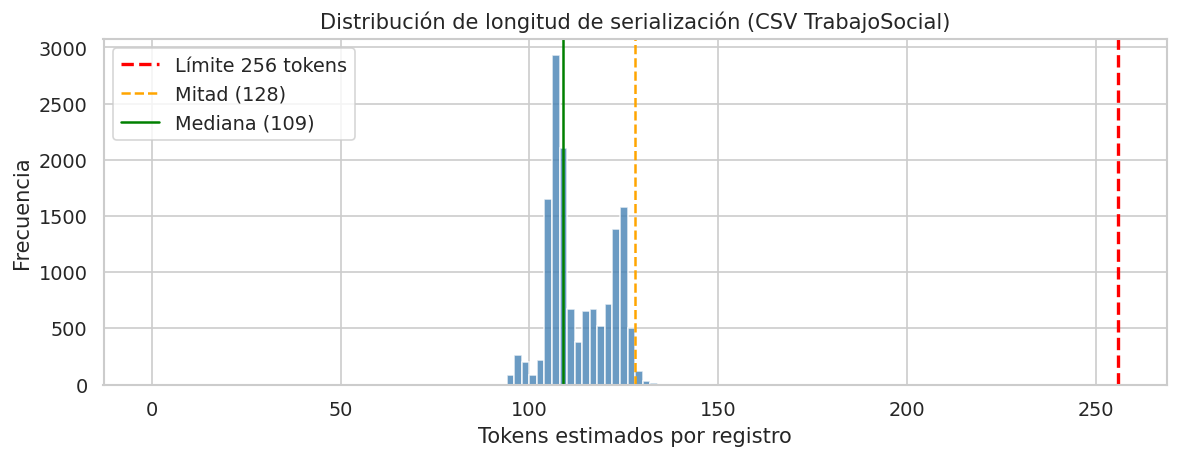

In [4]:
# ── 3.2  Estimación de tokens por registro serializado ────────────────────────
bloques_real = {}
for blk, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    if cols_exist:
        bloques_real[blk] = cols_exist

def estimar_tokens_registro(row):
    total = 0
    for blk, cols in bloques_real.items():
        vals_bloque = {c: row[c] for c in cols}
        if not any(pd.notna(v) for v in vals_bloque.values()):
            continue
        total += 1  # [BLK_X]
        for col_name, val in vals_bloque.items():
            total += 1  # [COL]
            total += len(str(col_name).split())
            if pd.isna(val):
                total += 1  # [VAL_NULL]
            else:
                total += 1  # [VAL]
                val_str = str(val)
                if col_name == 'EXPEDIENTE':
                    total += 2  # <UID> </UID>
                if 'FECHA' in col_name:
                    total += 2  # <DATE> </DATE>
                    val_str = str(val)[:10]
                total += len(val_str.split())
    return total

token_counts = df.apply(estimar_tokens_registro, axis=1)

# Tabla de estadísticas
exceden_128 = int((token_counts > 128).sum())
exceden_256 = int((token_counts > 256).sum())

df_token_stats = pd.DataFrame([
    {'Métrica': 'Mínimo', 'Tokens': int(token_counts.min())},
    {'Métrica': 'Mediana', 'Tokens': int(token_counts.median())},
    {'Métrica': 'Media', 'Tokens': round(token_counts.mean(), 1)},
    {'Métrica': 'P90', 'Tokens': int(token_counts.quantile(0.9))},
    {'Métrica': 'P95', 'Tokens': int(token_counts.quantile(0.95))},
    {'Métrica': 'P99', 'Tokens': int(token_counts.quantile(0.99))},
    {'Métrica': 'Máximo', 'Tokens': int(token_counts.max())},
    {'Métrica': 'Exceden 128', 'Tokens': f'{exceden_128} ({exceden_128/len(df)*100:.1f}%)'},
    {'Métrica': 'Exceden 256', 'Tokens': f'{exceden_256} ({exceden_256/len(df)*100:.1f}%)'},
])
display(df_token_stats.style.set_caption('Estimación de tokens por registro serializado')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

# Histograma
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=range(0, int(token_counts.max()) + 5, 2),
        color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(256, color='red', linestyle='--', linewidth=2, label='Límite 256 tokens')
ax.axvline(128, color='orange', linestyle='--', linewidth=1.5, label='Mitad (128)')
ax.axvline(token_counts.median(), color='green', linestyle='-', linewidth=1.5,
           label=f'Mediana ({token_counts.median():.0f})')
ax.set_xlabel('Tokens estimados por registro')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud de serialización (CSV TrabajoSocial)')
ax.legend()
plt.tight_layout()
plt.savefig(ruta_base / 'Reporte_Consultoría' / 'Figuras' / 'histograma_tokens_ts.png', dpi=150)
plt.show()

## 4. Resumen — Hallazgos Orientados a Record Linkage

### 4.1 Campos Críticos para Serialización

| Campo | Hallazgo | Impacto RL |
|-------|----------|------------|
| **NOMBRE (3 campos)** | Separados en AP/AM/NOMBRE; AP: 1 nulo, AM: 99 nulos (0.7%), NOMBRE: 19 nulos. Caracteres problemáticos: `.` (225 total, "MA."), NBSP (58), pipes, slashes ("R/N", "S/R") | Concatenar y normalizar; alinear con formato único de Económico y Comorbilidad |
| **EDAD** | 100% texto libre ("X años Y meses Z días"); mediana 52, rango 0–104. 651 nulos (4.4%) | Extraer años como entero; FECHA DE NACIMIENTO es más confiable |
| **EXPEDIENTE** | 100% numérico, 0 nulos, 14,795 únicos / 14,796 registros (ratio 1.00), rango [236,215–251,119]. 0 nombres conflictivos | Blocking key principal — excelente calidad |
| **NO. HISTORIA** | 14,794 formato IAN######; 2 atípicos | Blocking key alternativa exclusiva de este CSV |
| **DIAGNOSTICO** | 61.3% nulo (9,070 registros); texto libre con 3,303 categorías | Impacto limitado por alta nulidad; evaluar exclusión |

### 4.2 Bloques Semánticos

| Bloque | Cols | % Completo | Nota |
|--------|------|------------|------|
| `[BLK_ID]` | 6 | 94.7% | El más rico: AP, AM, NOMBRE, EDAD, FECHA NAC, GENERO |
| `[BLK_CLIN]` | 1 | 38.7% | Solo DIAGNOSTICO — 61.3% nulo |
| `[BLK_GEO]` | 2 | 98.3% | DELEGACIÓN + ESTADO — exclusivo de este CSV |
| `[BLK_SOCIO]` | 5 | 93.8% | ESCOLARIDAD, OCUPACIÓN, DERECHOHABIENTE, PUNTOS, NIVEL |
| `[BLK_ADMIN]` | 5 | 72.2% | EXPEDIENTE + NO. HISTORIA + FECHA ELAB (27.8% nula) + AÑO + FILA |

### 4.3 Presupuesto de Tokens

| Métrica | Valor |
|---------|-------|
| Mediana | 109 |
| P95 | 124 |
| Máximo | 132 |
| Exceden 128 | 45 (0.3%) |
| **Exceden 256** | **0 (0.0%)** |

Holgura amplia: incluso en P99 (127) se mantiene muy por debajo de 256. No se requiere truncamiento.

### 4.4 Inconsistencias Categóricas

- **ESCOLARIDAD**: 49 → 25 categorías al normalizar (trailing spaces, duplicados por case)
- **DERECHOHABIENTE**: 29 → 23 categorías al normalizar
- **DIAGNOSTICO**: 3,303+ categorías — texto libre, singletons masivos
- **DELEGACIÓN / ESTADO**: ESTADO tiene formato "México,Mexico" (coma embebida)

### 4.5 Acciones Recomendadas Pre-Serialización

1. **Concatenar nombre**: `AP + AM + NOMBRE` → formato unificado
2. **Limpiar caracteres**: eliminar `.`, NBSP, pipes, slashes de campos de nombre
3. **Parsear EDAD**: extraer años como entero; FECHA DE NACIMIENTO como referencia
4. **Normalizar categóricas**: strip + upper en ESCOLARIDAD, OCUPACIÓN, DERECHOHABIENTE, GENERO
5. **Separar ESTADO/PAIS**: resolver "México,Mexico" → campo unificado
6. **DIAGNOSTICO**: con 61.3% nulo, considerar `[VAL_NULL]` por defecto o excluir de bloques
7. **Eliminar col vacía**: Unnamed:19 (no aporta información)
8. **AÑO y FILA**: metadatos internos — evaluar exclusión del bloque serializado